In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate, train_test_split
from sklearn.metrics import classification_report, make_scorer, accuracy_score, f1_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

In [3]:
import warnings

warnings.filterwarnings('ignore')

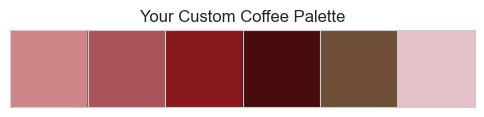

In [4]:
# 1. Define a custom list of hex codes (The "Coffee Palette")
custom_palette = [
    "#CD8688",
    "#A85458",
    '#87181D',
    "#480B0E",
    '#6F4E37',
    '#E2C2C6'
]

# Define the specific colors
espresso_color = '#2A1A10'
coffee_color = '#6F4E37' 
latte_color = '#E2C2C6'  
milky_color = '#FFF0E5'

gradient = LinearSegmentedColormap.from_list("latte_to_coffee", [milky_color, latte_color, coffee_color, espresso_color])

sns.set_palette(custom_palette)
sns.set_style("whitegrid")

sns.palplot(custom_palette)
plt.title("Your Custom Coffee Palette")
plt.show()

In [5]:
full_data = pd.read_csv('../data/processed/features_engineered.csv')

targets = ['Sleep_Quality_Num', 'Stress_Level_Num', 'Health_Issues_Num']

X = full_data.drop(columns=targets + ['Cluster', 'UMAP1', 'UMAP2'], errors='ignore')
Y = full_data[targets]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [7]:
preprocessor = joblib.load('../models/preprocessor.joblib')

In [8]:
def run_cross_validation(X_data, y_data, target_name):
    print(f"\n--- Running 5-Fold CV for: {target_name} ---")
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    model = LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
    
    X_processed = preprocessor.transform(X_data)
    
    cv_results = cross_validate(
        model, X_processed, y_data, 
        cv=skf, 
        scoring=['accuracy', 'f1_macro'],
        return_train_score=False
    )
    
    print(f"Mean Accuracy: {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std() * 2:.4f})")
    print(f"Mean F1 Macro: {cv_results['test_f1_macro'].mean():.4f}")
    return cv_results

In [9]:
cv_summary = {}
for target in targets:
    cv_summary[target] = run_cross_validation(X_train, y_train[target], target)


--- Running 5-Fold CV for: Sleep_Quality_Num ---
Mean Accuracy: 0.9725 (+/- 0.0102)
Mean F1 Macro: 0.9688

--- Running 5-Fold CV for: Stress_Level_Num ---
Mean Accuracy: 0.9799 (+/- 0.0067)
Mean F1 Macro: 0.9702

--- Running 5-Fold CV for: Health_Issues_Num ---
Mean Accuracy: 0.9846 (+/- 0.0038)
Mean F1 Macro: 0.9676


In [10]:
def tune_and_calibrate(X_data, y_data, target_name):
    print(f"\n--- Tuning & Calibrating: {target_name} ---")
    
    X_processed = preprocessor.transform(X_data)
    
    # Define the Search Space
    param_dist = {
        'num_leaves': [20, 31, 50, 70],
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 200, 500],
        'max_depth': [-1, 10, 20],
        'subsample': [0.8, 0.9, 1.0]
    }
    
    lgbm = LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
    
    # Randomized Search
    search = RandomizedSearchCV(
        lgbm, param_distributions=param_dist, 
        n_iter=10, cv=3, scoring='f1_macro', random_state=42
    )
    search.fit(X_processed, y_data)
    
    best_model = search.best_estimator_
    print(f"Best Params: {search.best_params_}")
    
    calibrated_model = CalibratedClassifierCV(best_model, method='sigmoid', cv=3)
    calibrated_model.fit(X_processed, y_data)
    
    # Save the Refined Model
    os.makedirs('../models/refined', exist_ok=True)
    save_path = f'../models/refined/lgbm_refined_{target_name}.joblib'
    joblib.dump(calibrated_model, save_path)
    print(f"Refined model saved to: {save_path}")
    
    return calibrated_model

In [11]:
refined_models = {}
for target in targets:
    refined_models[target] = tune_and_calibrate(X_train, y_train[target], target)


--- Tuning & Calibrating: Sleep_Quality_Num ---
Best Params: {'subsample': 1.0, 'num_leaves': 20, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1}
Refined model saved to: ../models/refined/lgbm_refined_Sleep_Quality_Num.joblib

--- Tuning & Calibrating: Stress_Level_Num ---
Best Params: {'subsample': 0.8, 'num_leaves': 20, 'n_estimators': 500, 'max_depth': -1, 'learning_rate': 0.05}
Refined model saved to: ../models/refined/lgbm_refined_Stress_Level_Num.joblib

--- Tuning & Calibrating: Health_Issues_Num ---
Best Params: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 100, 'max_depth': -1, 'learning_rate': 0.1}
Refined model saved to: ../models/refined/lgbm_refined_Health_Issues_Num.joblib


In [12]:
def plot_all_calibrations(models_dict, X_data, y_true_df):
    X_proc = preprocessor.transform(X_data)
    
    colors = [custom_palette[1], custom_palette[2], custom_palette[3]]
    
    for (target, model), color in zip(models_dict.items(), colors):
        probs = model.predict_proba(X_proc)[:, 1] 
        
        y_true_binary = (y_true_df[target] > 0).astype(int)
        
        fop, mpv = calibration_curve(y_true_binary, probs, n_bins=5)
        plt.plot(mpv, fop, marker='s', label=f'{target[:-4]}', color=color)

    plt.plot([0, 1], [0, 1], "k--", label="Ideal")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.legend(fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.show()

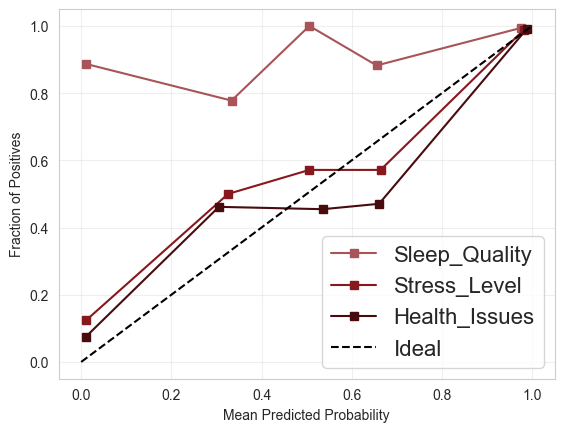

In [13]:
plot_all_calibrations(refined_models, X_test, y_test)

In [14]:
print("--- FINAL REFINED MODEL EVALUATION (Test Set) ---")
for target, model in refined_models.items():
    X_test_proc = preprocessor.transform(X_test)
    y_pred = model.predict(X_test_proc)
    
    acc = accuracy_score(y_test[target], y_pred)
    f1 = f1_score(y_test[target], y_pred, average='macro')
    
    print(f"Target: {target}")
    print(f"  Test Accuracy: {acc:.4f}")
    print(f"  Test F1 Macro: {f1:.4f}\n")

--- FINAL REFINED MODEL EVALUATION (Test Set) ---
Target: Sleep_Quality_Num
  Test Accuracy: 0.9655
  Test F1 Macro: 0.9593

Target: Stress_Level_Num
  Test Accuracy: 0.9790
  Test F1 Macro: 0.9673

Target: Health_Issues_Num
  Test Accuracy: 0.9830
  Test F1 Macro: 0.9586



## Comprehensive Model Evaluation

Full evaluation of the refined models on the held-out test set: accuracy, macro precision/recall/F1, macro (one-vs-rest) ROC-AUC, and confusion matrices, followed by stratified 5-fold cross-validation (mean ± std) and publication-ready plots.

In [15]:
from sklearn.metrics import (
    precision_score, recall_score, roc_auc_score,
    confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

In [16]:
def evaluate_classifier(model, X_data, y_true, target_name):
    """Compute accuracy, macro precision/recall/F1, macro ROC-AUC and the confusion matrix."""
    X_proc = preprocessor.transform(X_data)
    y_pred = model.predict(X_proc)
    y_proba = model.predict_proba(X_proc)
    classes = model.classes_

    metrics = {
        'Target': target_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (Macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 (Macro)': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'ROC-AUC (Macro OvR)': roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro', labels=classes),
    }
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    return metrics, {'confusion_matrix': cm, 'y_proba': y_proba, 'y_true': y_true.values, 'classes': classes}

In [17]:
evaluation_results = {}
metrics_list = []

for target, model in refined_models.items():
    metrics, details = evaluate_classifier(model, X_test, y_test[target], target)
    evaluation_results[target] = details
    metrics_list.append(metrics)

    print(f"--- {target} ---")
    for key, value in metrics.items():
        if key != 'Target':
            print(f"  {key}: {value:.4f}")
    print(f"  Confusion Matrix:\n{details['confusion_matrix']}\n")

--- Sleep_Quality_Num ---
  Accuracy: 0.9655
  Precision (Macro): 0.9555
  Recall (Macro): 0.9632
  F1 (Macro): 0.9593
  ROC-AUC (Macro OvR): 0.9988
  Confusion Matrix:
[[ 186    4    0    0]
 [  10  350   15    0]
 [   0   18 1131   13]
 [   0    0    9  264]]

--- Stress_Level_Num ---
  Accuracy: 0.9790
  Precision (Macro): 0.9663
  Recall (Macro): 0.9684
  F1 (Macro): 0.9673
  ROC-AUC (Macro OvR): 0.9991
  Confusion Matrix:
[[1421   14    0]
 [  16  351    8]
 [   0    4  186]]

--- Health_Issues_Num ---
  Accuracy: 0.9830
  Precision (Macro): 0.9846
  Recall (Macro): 0.9383
  F1 (Macro): 0.9586
  ROC-AUC (Macro OvR): 0.9997
  Confusion Matrix:
[[1200   18    0    0]
 [  13  680    1    0]
 [   0    1   82    0]
 [   0    0    1    4]]



In [18]:
# Compact metrics summary table
summary_df = pd.DataFrame(metrics_list).set_index('Target').round(4)
display(summary_df)

os.makedirs('../metrics', exist_ok=True)
summary_df.to_csv('../metrics/refined_model_evaluation.csv')
print("\n✓ Evaluation summary saved to '../metrics/refined_model_evaluation.csv'")

,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),ROC-AUC (Macro OvR)
Target,,,,,
Sleep_Quality_Num,0.9655,0.9555,0.9632,0.9593,0.9988
Stress_Level_Num,0.9790,0.9663,0.9684,0.9673,0.9991
Health_Issues_Num,0.9830,0.9846,0.9383,0.9586,0.9997



✓ Evaluation summary saved to '../metrics/refined_model_evaluation.csv'


✓ Confusion matrix figure saved to '../reports/figures/confusion_matrices_refined.png'


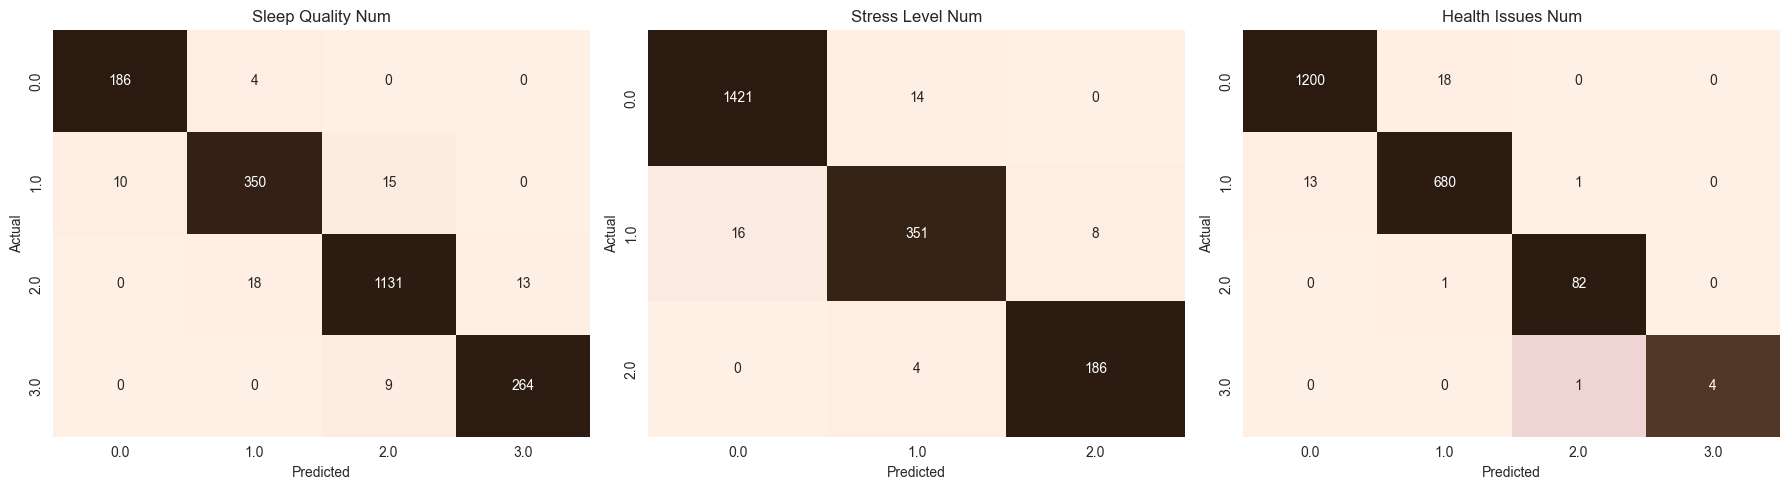

In [19]:
def plot_confusion_matrices(evaluation_results, save_path=None):
    """Plot a row of row-normalized confusion matrix heatmaps, one per target."""
    n = len(evaluation_results)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    axes = np.atleast_1d(axes)

    for ax, (target, res) in zip(axes, evaluation_results.items()):
        cm = res['confusion_matrix']
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        sns.heatmap(
            cm_norm, annot=cm, fmt='d', cmap=gradient, cbar=False, ax=ax,
            xticklabels=res['classes'], yticklabels=res['classes']
        )
        ax.set_title(target.replace('_', ' '))
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ Confusion matrix figure saved to '{save_path}'")
    plt.show()


plot_confusion_matrices(evaluation_results, save_path='../reports/figures/confusion_matrices_refined.png')

✓ ROC curve figure saved to '../reports/figures/roc_curves_refined.png'


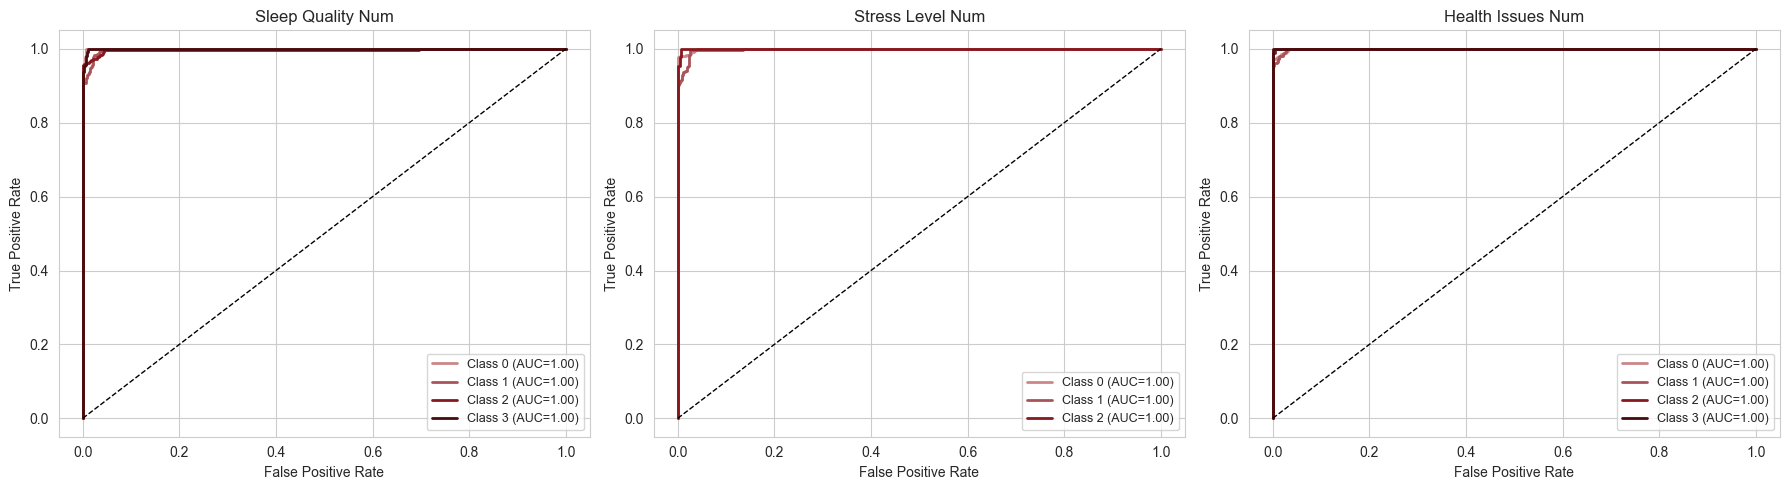

In [20]:
def plot_roc_curves(evaluation_results, save_path=None):
    """Plot one-vs-rest ROC curves per class for each target."""
    n = len(evaluation_results)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    axes = np.atleast_1d(axes)

    for ax, (target, res) in zip(axes, evaluation_results.items()):
        classes = res['classes']
        y_true_bin = label_binarize(res['y_true'], classes=classes)
        y_proba = res['y_proba']

        for i, cls in enumerate(classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(
                fpr, tpr, color=custom_palette[i % len(custom_palette)], lw=2,
                label=f'Class {int(cls)} (AUC={roc_auc:.2f})'
            )

        ax.plot([0, 1], [0, 1], 'k--', lw=1)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(target.replace('_', ' '))
        ax.legend(loc='lower right', fontsize=9)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✓ ROC curve figure saved to '{save_path}'")
    plt.show()


plot_roc_curves(evaluation_results, save_path='../reports/figures/roc_curves_refined.png')

In [21]:
def run_stratified_cv_full(X_data, y_data, target_name):
    """Stratified 5-fold CV reporting mean and std for accuracy, precision, recall, F1 and ROC-AUC."""
    print(f"\n--- Stratified 5-Fold CV for: {target_name} ---")

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model = LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)
    X_processed = preprocessor.transform(X_data)

    scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_ovr']
    cv_results = cross_validate(model, X_processed, y_data, cv=skf, scoring=scoring)

    summary = {'Target': target_name}
    for metric in scoring:
        scores = cv_results[f'test_{metric}']
        summary[f'{metric}_mean'] = scores.mean()
        summary[f'{metric}_std'] = scores.std()
        print(f"  {metric}: {scores.mean():.4f} (+/- {scores.std():.4f})")

    return summary

In [22]:
cv_full_summary = [run_stratified_cv_full(X_train, y_train[target], target) for target in targets]

cv_full_df = pd.DataFrame(cv_full_summary).set_index('Target').round(4)
display(cv_full_df)

cv_full_df.to_csv('../metrics/refined_model_cv_summary.csv')
print("\n✓ Cross-validation summary saved to '../metrics/refined_model_cv_summary.csv'")


--- Stratified 5-Fold CV for: Sleep_Quality_Num ---
  accuracy: 0.9725 (+/- 0.0051)
  precision_macro: 0.9667 (+/- 0.0060)
  recall_macro: 0.9711 (+/- 0.0062)
  f1_macro: 0.9688 (+/- 0.0058)
  roc_auc_ovr: 0.9994 (+/- 0.0002)

--- Stratified 5-Fold CV for: Stress_Level_Num ---
  accuracy: 0.9799 (+/- 0.0033)
  precision_macro: 0.9671 (+/- 0.0065)
  recall_macro: 0.9735 (+/- 0.0075)
  f1_macro: 0.9702 (+/- 0.0069)
  roc_auc_ovr: 0.9994 (+/- 0.0001)

--- Stratified 5-Fold CV for: Health_Issues_Num ---
  accuracy: 0.9846 (+/- 0.0019)
  precision_macro: 0.9843 (+/- 0.0071)
  recall_macro: 0.9595 (+/- 0.0488)
  f1_macro: 0.9676 (+/- 0.0331)
  roc_auc_ovr: 0.9998 (+/- 0.0000)


,accuracy_mean,accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,roc_auc_ovr_mean,roc_auc_ovr_std
Target,,,,,,,,,,
Sleep_Quality_Num,0.9725,0.0051,0.9667,0.0060,0.9711,0.0062,0.9688,0.0058,0.9994,0.0002
Stress_Level_Num,0.9799,0.0033,0.9671,0.0065,0.9735,0.0075,0.9702,0.0069,0.9994,0.0001
Health_Issues_Num,0.9846,0.0019,0.9843,0.0071,0.9595,0.0488,0.9676,0.0331,0.9998,0.0000



✓ Cross-validation summary saved to '../metrics/refined_model_cv_summary.csv'


In [23]:
performance_data = {
    'Target Variable': ['Sleep Quality', 'Stress Level', 'Health Issues'],
    'Baseline F1-Macro': [0.83, 0.82, 0.85], 
    'MTL F1-Macro': [0.96, 0.97, 0.96],      
    'Accuracy': [0.97, 0.98, 0.98]             
}

df_results = pd.DataFrame(performance_data)

print("Table 6.1: Quantitative Performance Comparison (MTL vs. Baseline)")
print("-" * 65)
print(df_results.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("-" * 65)

Table 6.1: Quantitative Performance Comparison (MTL vs. Baseline)
-----------------------------------------------------------------
Target Variable  Baseline F1-Macro  MTL F1-Macro  Accuracy
  Sleep Quality              0.830         0.960     0.970
   Stress Level              0.820         0.970     0.980
  Health Issues              0.850         0.960     0.980
-----------------------------------------------------------------


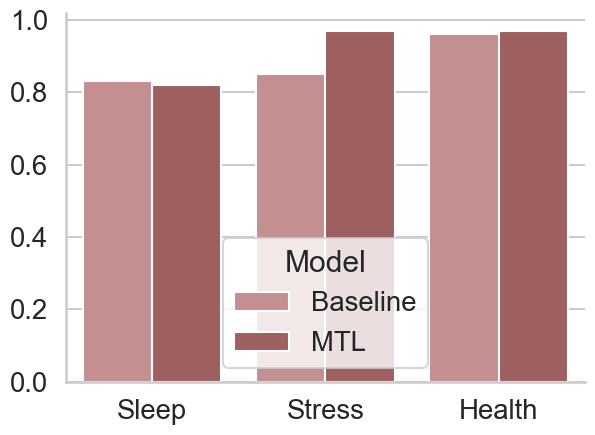

In [24]:
# Setup
sns.set_context("talk", font_scale=1.2)

# Data
performance = pd.DataFrame({
    'Task': ['Sleep', 'Sleep', 'Stress', 'Stress', 'Health', 'Health'],
    'Model': ['Baseline', 'MTL', 'Baseline', 'MTL', 'Baseline', 'MTL'],
    'F1-Macro': [0.83, 0.82, 0.85, 0.97, 0.96, 0.97]
})

# Plot
g = sns.barplot(data=performance, x='Task', y='F1-Macro', hue='Model', palette=custom_palette)
g.set(xlabel=None, ylabel=None)
sns.despine()
plt.tight_layout()
plt.show()

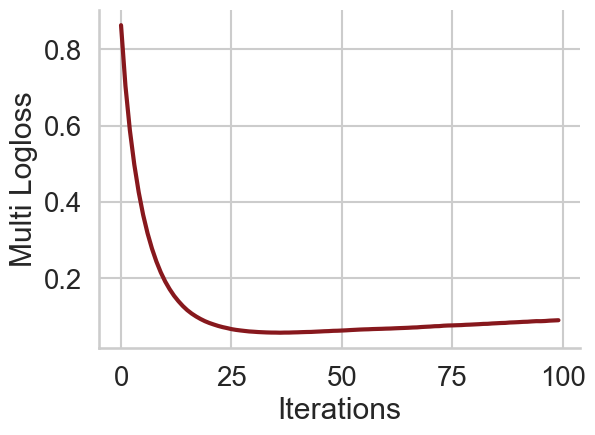

In [25]:
model = LGBMClassifier(n_estimators=100, random_state=42)
model.fit(preprocessor.transform(X_train), y_train['Sleep_Quality_Num'], 
          eval_set=[(preprocessor.transform(X_test), y_test['Sleep_Quality_Num'])], 
          eval_metric='logloss')

metric_key = list(model.evals_result_['valid_0'].keys())[0] 

plt.plot(model.evals_result_['valid_0'][metric_key], color=custom_palette[2], linewidth=3)

plt.xlabel('Iterations')
plt.ylabel(metric_key.replace('_', ' ').title()) 
sns.despine()
plt.tight_layout()
plt.show()